In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score

df = pd.read_parquet(r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src\cbl\data\merged.parquet")
print(f"Full dataset: {len(df)} samples")

Full dataset: 191872 samples


instead of taking this subset approach we can also go stratified sampling either proportionate or disproportionate  
make sure to use the interpolated data

In [2]:
CLASS_NAMES = ['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino']
print("\nClass counts:")
for col in CLASS_NAMES:
    print(f"  {col}: {int(df[col].sum())} ({df[col].mean()*100:.2f}%)")
    
# Keep all sulfonic acid (77) and guanidino (3145) samples
# Random forest can train on full dataset unlike KNN, but we still
# oversample rare classes to ensure good representation
mask_rare = (df['sulfonic_acid'] == 1) | (df['guanidino'] == 1)
df_rare   = df[mask_rare]
df_common = df[~mask_rare].sample(n=10000, random_state=42)
df_sub    = pd.concat([df_rare, df_common]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Subset size: {len(df_sub)} samples")
for col in CLASS_NAMES:
    print(f"  {col}: {int(df_sub[col].sum())}")

X = np.stack(df_sub['transmittance'].values)
y = df_sub[CLASS_NAMES].values

# Stratify jointly on sulfonic acid + guanidino
strata = df_sub['sulfonic_acid'].astype(str) + df_sub['guanidino'].astype(str)

# 70/15/15 split — val set used for threshold tuning, test set truly held out
X_train, X_temp, y_train, y_temp, strata_train, strata_temp = train_test_split(
    X, y, strata, test_size=0.3, random_state=42, stratify=strata)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nTrain: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")


Class counts:
  carboxylic_acid: 79005 (41.18%)
  amino: 116276 (60.60%)
  sulfonic_acid: 77 (0.04%)
  guanidino: 3145 (1.64%)
Subset size: 13215 samples
  carboxylic_acid: 4427
  amino: 7820
  sulfonic_acid: 77
  guanidino: 3145

Train: (9250, 1800)
Val:   (1982, 1800)
Test:  (1983, 1800)


In [3]:

print("\nTraining Random Forest...")
rf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators  = 300,
        class_weight  = 'balanced',
        random_state  = 42,
        n_jobs        = -1
    )
)
rf.fit(X_train, y_train)
print("Done")


Training Random Forest...
Done


In [4]:
y_proba_val = np.array([est.predict_proba(X_val)[:, 1]
                        for est in rf.estimators_]).T

thresholds_to_try = np.arange(0.05, 0.65, 0.05)

print("Optimal thresholds on validation set:")
optimal_thresholds = []

for i, class_name in enumerate(CLASS_NAMES):
    best_t, best_f1 = 0.5, 0
    for t in thresholds_to_try:
        preds = (y_proba_val[:, i] > t).astype(int)
        f1 = f1_score(y_val[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    optimal_thresholds.append(best_t)
    print(f"  {class_name:<20}: threshold={best_t:.2f}  val F1={best_f1:.3f}")

Optimal thresholds on validation set:
  carboxylic_acid     : threshold=0.50  val F1=0.972
  amino               : threshold=0.60  val F1=0.993
  sulfonic_acid       : threshold=0.20  val F1=0.560
  guanidino           : threshold=0.35  val F1=0.874


In [5]:
y_proba_test = np.array([est.predict_proba(X_test)[:, 1]
                         for est in rf.estimators_]).T

y_pred = np.column_stack([
    (y_proba_test[:, i] > optimal_thresholds[i]).astype(int)
    for i in range(len(CLASS_NAMES))
])

print("Random Forest — tuned thresholds — test set results:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro', zero_division=0):.3f}")

Random Forest — tuned thresholds — test set results:
                 precision    recall  f1-score   support

carboxylic_acid       0.99      0.96      0.98       661
          amino       0.99      0.99      0.99      1170
  sulfonic_acid       0.60      0.60      0.60        10
      guanidino       0.91      0.85      0.88       478

      micro avg       0.97      0.95      0.96      2319
      macro avg       0.87      0.85      0.86      2319
   weighted avg       0.97      0.95      0.96      2319
    samples avg       0.95      0.95      0.95      2319

Macro F1: 0.861


using balanced_subsample instead

In [7]:
rf_bs = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators = 300,
        class_weight = 'balanced_subsample',
        random_state = 42,
        n_jobs       = -1
    )
)
rf_bs.fit(X_train, y_train)

# Find optimal thresholds on validation set
y_proba_val_bs = np.array([est.predict_proba(X_val)[:, 1]
                            for est in rf_bs.estimators_]).T

print("Optimal thresholds (balanced_subsample):")
optimal_thresholds_bs = []
for i, class_name in enumerate(CLASS_NAMES):
    best_t, best_f1 = 0.5, 0
    for t in thresholds_to_try:
        preds = (y_proba_val_bs[:, i] > t).astype(int)
        f1 = f1_score(y_val[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    optimal_thresholds_bs.append(best_t)
    print(f"  {class_name:<20}: threshold={best_t:.2f}  val F1={best_f1:.3f}")

# Evaluate on test set
y_proba_test_bs = np.array([est.predict_proba(X_test)[:, 1]
                             for est in rf_bs.estimators_]).T

y_pred_bs = np.column_stack([
    (y_proba_test_bs[:, i] > optimal_thresholds_bs[i]).astype(int)
    for i in range(len(CLASS_NAMES))
])

print("\nRF balanced_subsample — test set results:")
print(classification_report(y_test, y_pred_bs, target_names=CLASS_NAMES, zero_division=0))
print(f"Macro F1: {f1_score(y_test, y_pred_bs, average='macro', zero_division=0):.3f}")

Optimal thresholds (balanced_subsample):
  carboxylic_acid     : threshold=0.45  val F1=0.974
  amino               : threshold=0.60  val F1=0.993
  sulfonic_acid       : threshold=0.15  val F1=0.593
  guanidino           : threshold=0.35  val F1=0.875

RF balanced_subsample — test set results:
                 precision    recall  f1-score   support

carboxylic_acid       0.98      0.98      0.98       661
          amino       0.99      0.99      0.99      1170
  sulfonic_acid       0.57      0.80      0.67        10
      guanidino       0.92      0.84      0.88       478

      micro avg       0.97      0.95      0.96      2319
      macro avg       0.87      0.90      0.88      2319
   weighted avg       0.97      0.95      0.96      2319
    samples avg       0.95      0.95      0.95      2319

Macro F1: 0.879


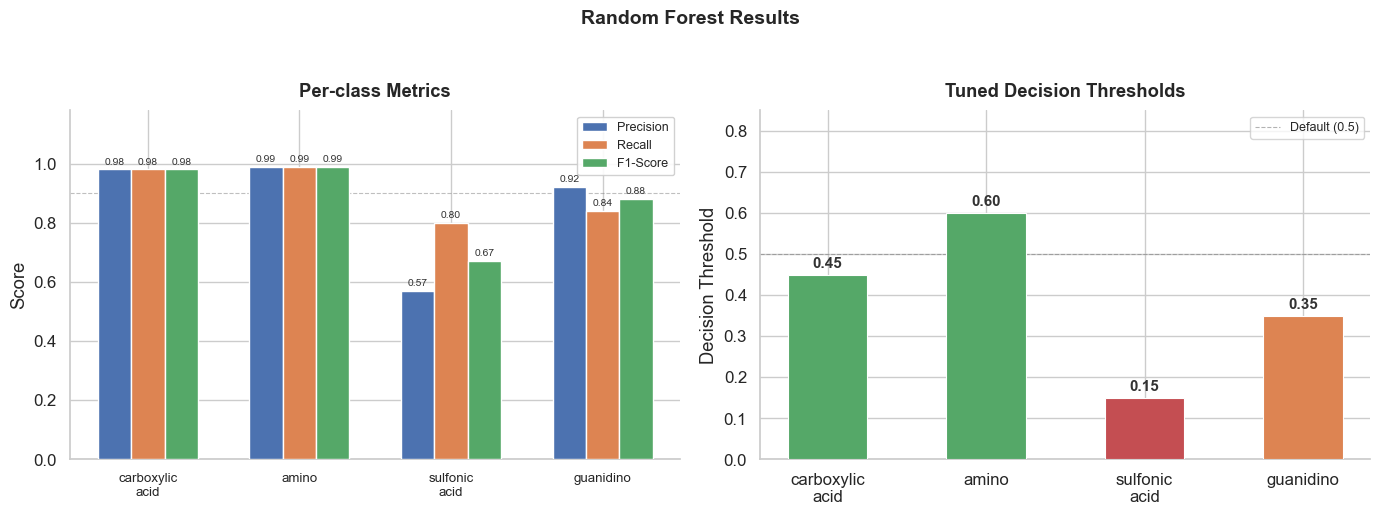

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.1)

CLASS_NAMES_DISPLAY = ['carboxylic\nacid', 'amino', 'sulfonic\nacid', 'guanidino']
BLUE   = "#4C72B0"
ORANGE = "#DD8452"
GREEN  = "#55A868"
RED    = "#C44E52"

# ── Results data ────────────────────────────────────────────────────────────
precision = [0.98, 0.99, 0.57, 0.92]
recall    = [0.98, 0.99, 0.80, 0.84]
f1        = [0.98, 0.99, 0.67, 0.88]
support   = [661, 1170, 10, 478]

model_names   = ['KNN\nk=7', 'SVM Linear\nC=10', 'RF balanced\n(tuned)', 'RF bal_subsample\n(tuned)']
macro_f1s     = [0.77, 0.78, 0.861, 0.879]
weighted_f1s  = [0.95, 0.96, 0.96,  0.96]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest Results', 
             fontsize=14, fontweight='bold', y=1.03)

# ── Plot 1: Per-class metrics ────────────────────────────────────────────────
ax = axes[0]
x, w = np.arange(len(CLASS_NAMES_DISPLAY)), 0.22
b1 = ax.bar(x - w, precision, w, label='Precision', color=BLUE,   zorder=3)
b2 = ax.bar(x,     recall,    w, label='Recall',    color=ORANGE, zorder=3)
b3 = ax.bar(x + w, f1,        w, label='F1-Score',  color=GREEN,  zorder=3)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES_DISPLAY, fontsize=9.5)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Per-class Metrics', fontweight='bold', pad=10)
ax.axhline(0.9, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.legend(framealpha=0.9, fontsize=9)
sns.despine(ax=ax, left=False)


# ── Plot 3: Optimal thresholds per class ────────────────────────────────────
ax = axes[1]
thresholds     = [0.45, 0.60, 0.15, 0.35]
threshold_colors = [GREEN, GREEN, RED, ORANGE]  # red = very low = rare class

bars = ax.bar(CLASS_NAMES_DISPLAY, thresholds, color=threshold_colors,
              width=0.5, zorder=3, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, thresholds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#333333')

ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.6, label='Default (0.5)')
ax.set_ylim(0, 0.85)
ax.set_ylabel('Decision Threshold')
ax.set_title('Tuned Decision Thresholds', fontweight='bold', pad=10)
ax.legend(fontsize=9)
sns.despine(ax=ax, left=False)

plt.tight_layout()
plt.savefig('rf_results.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\20242732\AppData\Local\Temp\ipykernel_17924\1200633327.py:52: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\20242732\AppData\Local\Temp\ipykernel_17924\1200633327.py:53: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig('feature_importance_bands.png', dpi=150, bbox_inches='tight')
C:\Users\20242732\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


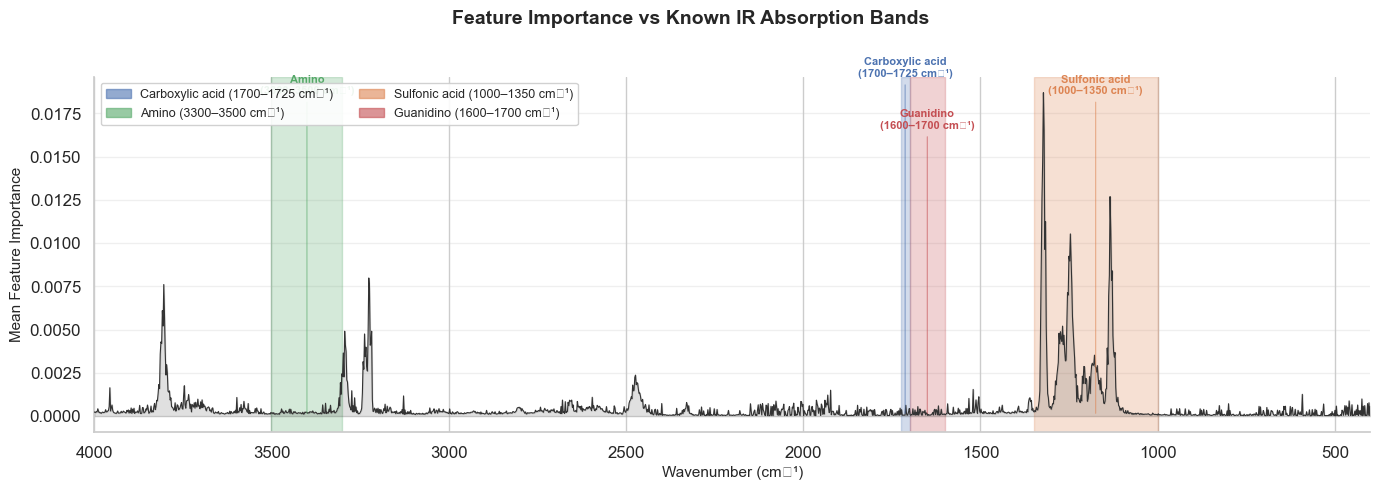

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

importances = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
wavenumbers = np.linspace(4000, 400, 1800)

ABSORPTION_BANDS = {
    'Carboxylic acid\n(1700–1725 cm⁻¹)': (1700, 1725, '#4C72B0'),
    'Amino\n(3300–3500 cm⁻¹)':           (3300, 3500, '#55A868'),
    'Sulfonic acid\n(1000–1350 cm⁻¹)':   (1000, 1350, '#DD8452'),
    'Guanidino\n(1600–1700 cm⁻¹)':       (1600, 1700, '#C44E52'),
}

# Stagger heights for overlapping labels (carboxylic/guanidino are close)
LABEL_HEIGHTS = {
    'Carboxylic acid\n(1700–1725 cm⁻¹)': 0.0195,
    'Amino\n(3300–3500 cm⁻¹)':           0.0185,
    'Sulfonic acid\n(1000–1350 cm⁻¹)':   0.0185,
    'Guanidino\n(1600–1700 cm⁻¹)':       0.0165,  # lower to avoid overlap with carboxylic
}

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Feature Importance vs Known IR Absorption Bands',
             fontsize=14, fontweight='bold')

ax.plot(wavenumbers, importances, color='#333333', lw=0.8, zorder=3)
ax.fill_between(wavenumbers, importances, alpha=0.15, color='#333333', zorder=2)

for label, (lo, hi, color) in ABSORPTION_BANDS.items():
    ax.axvspan(lo, hi, alpha=0.25, color=color, zorder=1)
    mid = (lo + hi) / 2
    ax.annotate(
        label,
        xy=(mid, 0),
        xytext=(mid, LABEL_HEIGHTS[label]),
        ha='center', va='bottom',
        fontsize=8, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.6)
    )

ax.set_xlim(4000, 400)
ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=11)
ax.set_ylabel('Mean Feature Importance', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

patches = [mpatches.Patch(color=c, alpha=0.6, label=l.replace('\n', ' '))
           for l, (_, _, c) in ABSORPTION_BANDS.items()]
ax.legend(handles=patches, fontsize=9, loc='upper left', framealpha=0.9, ncol=2)

plt.tight_layout()
plt.savefig('feature_importance_bands.png', dpi=150, bbox_inches='tight')
plt.show()